#  Cats Vs Dogs (Pretrained - Fine Tuning)

Hay 2 formas de usar una red preentrenada *feature extraction* y *fine-tuning*. 

En este *notebook* se profundiza en la tecnica *fine-tuning*.

El *fine tuning* es muy similar al *feature extraction* en el que se congela la base conbolucional y se reentrena el clasificador, pero en este caso **no** se congela **toda** la base convolucional. Se permite que las capas mas superiores se sigan reentrenando. 

Se pude desglosar en los siguientes puntos:
1. Añadir una red personalizada encima de la base convolucional.
2. Congela la base convolucional.
3. Entrenar la parte añadida.
4. Descongelar **algunas** capas de la base convolucional.
5. Entrenar ambas, las capas descongeladas y las añadida y entrenadas en la parte de encima.

En el notebook de [feature extraction](5.3.1.cats-vs-dogs-pretrained-fe.ipynb) completo hasta el paso 3 asi que vamos a cargar el modelo que guardamos en ese momento y continuaremos a partir de ahi.

In [2]:
from tensorflow import keras

model = keras.models.load_model('./models/cats_and_dogs_small_4.h5')
model.summary()

I0000 00:00:1753580341.593219  573166 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11398 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,355 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2 (12.00 B)

Recordar que *vgg16* es la base convolucional. Se mantendra en su mayor parte congelada a excepción de las ultimas 3 capas convolucionales.

In [3]:
conv_base = model.layers[0]
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [4]:
# Configura como entrenables las 3 ultimas capas desde 'block5_conv1'
conv_base.trainable = True
set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    layer.trainable = set_trainable

print('This is the number of trainable weights:', len(model.trainable_weights))

This is the number of trainable weights: 10


Reentrenar el modelo:

In [ ]:
import os

base_dir = os.path.expanduser('~/libros/dlwp/datasets/kaggle_original_data/cats_and_dogs_small')
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [7]:
from tensorflow.keras import optimizers

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-5),
              metrics=['acc'])

history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=50)

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200


I0000 00:00:1753580344.322804  573203 service.cc:152] XLA service 0x7fd824005910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753580344.322823  573203 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-07-26 22:39:04.362434: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753580344.716124  573203 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-07-26 22:39:05.015677: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.39 = (f32[20,64,150,150]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,3,150,150]{3,2,1,0} %bitcast.2044, f32[64,3,3,3]{3,2,1,0} %bitcast.2051, f32[64]{0} %bitcast.2053), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

  3/100 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - acc: 0.9306 - loss: 0.1614

I0000 00:00:1753580348.328421  573203 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - acc: 0.8791 - loss: 0.2844

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-07-26 22:39:18.371159: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.49 = (f32[20,512,9,9]{3,2,1,0}, u8[0]{0}) custom-call(f32[20,512,9,9]{3,2,1,0} %bitcast.826, f32[512,512,3,3]{3,2,1,0} %bitcast.833, f32[512]{0} %bitcast.835), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1_1/vgg16_1/block5_conv1_1/convolution" source_file="/home/sponte/libros/dlwp/tf-gpu/lib/python3.1

100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 118ms/step - acc: 0.8791 - loss: 0.2844 - val_acc: 0.9130 - val_loss: 0.2194
Epoch 2/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.9111 - loss: 0.2297 - val_acc: 0.9140 - val_loss: 0.2088
Epoch 3/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.9010 - loss: 0.2404 - val_acc: 0.9130 - val_loss: 0.2367
Epoch 4/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.9066 - loss: 0.2228 - val_acc: 0.9240 - val_loss: 0.1942
Epoch 5/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.9150 - loss: 0.1947 - val_acc: 0.9260 - val_loss: 0.1878
Epoch 6/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.9198 - loss: 0.1903 - val_acc: 0.9290 - val_loss: 0.1858
Epoch 7/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.9280 - loss: 0.1622 - val_acc: 0.9280 - val_loss: 0.1967
Epoch 8/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - acc: 0.9273 - loss: 0.1734 - val_acc: 0.9350 - val_loss: 0.1707
Epoch 9/200
100/100 ━━━━━━━━━━━━━━━━

In [8]:
model.save('./models/cats_and_dogs_small_5.h5')

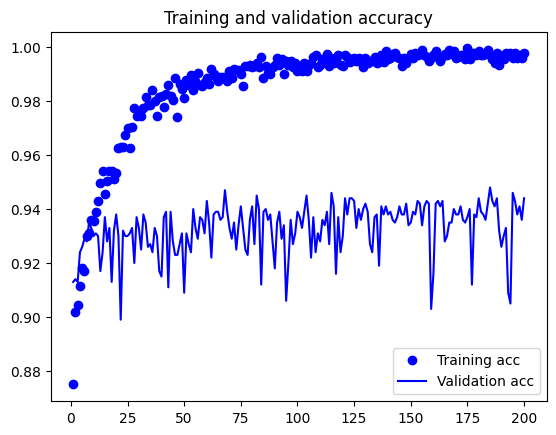

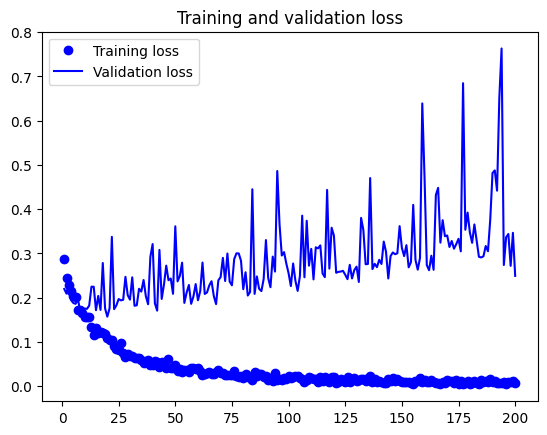

In [9]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

En el mejor momento *loss*=$0.19$, *acc*=$0.95$. Se ve overfittin a partir de la epoca 25.

Las curvas son un ruidosas, vamos a hacerlas mas legibles usando un movimiento exponencial promedio sobre los valores de *loss* y de *acc*

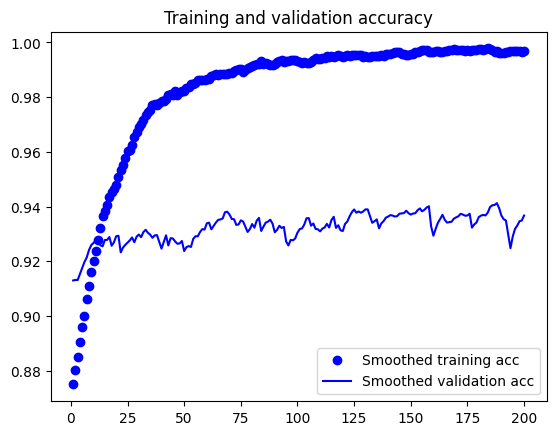

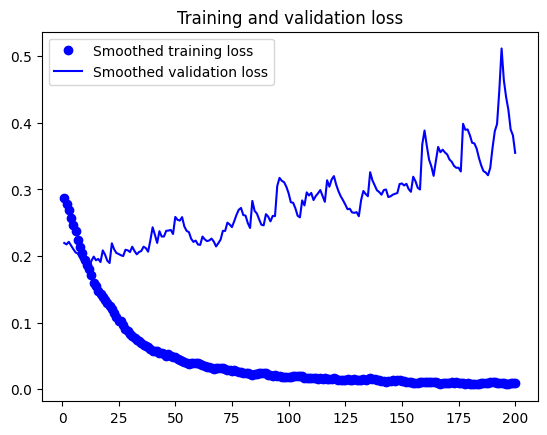

In [16]:
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points
    
plt.plot(epochs, smooth_curve(acc), 'bo', label='Smoothed training acc')
plt.plot(epochs, smooth_curve(val_acc), 'b', label='Smoothed validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, smooth_curve(loss), 'bo', label='Smoothed training loss')
plt.plot(epochs, smooth_curve(val_loss), 'b', label='Smoothed validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

En el mejor momento *loss*=$0.19$, *acc*=$0.94$. Notar que aunque los aumente acc mejora. Esto se debe a que *loss* tiene una naturaleza porcentual, mientras que a *acc* unicamente le importa que caiga dentro del porcentaje correcto, independientemente de si el *loss* es alto para esa prediccion. Por eso es que se puede dar que el *loss* aumente por que la frontera de decicion es mas ambigua y por tanto las predicciones menos confiables pero el *acc* mejore ya que estas predicciones cerca del limite son correctas.

Evaluar el modelo en los datos de *test*:

In [17]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

test_loss, test_acc = model.evaluate(test_generator, steps=50)
print('test acc:', test_acc)

Found 1000 images belonging to 2 classes.
 3/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9500 - loss: 0.3791

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9491 - loss: 0.3540
test acc: 0.9430000185966492


En la competencia original *dogs_vs_cats* $0.97$ seria un resultado entre los top de la competencia. 

Usando *deep learning* moderno se logro este resultad con apenas un 10% del dataset original. Hay una gran diferencia entre entrenar un modelo con 20.000 muestras respecto a entrenarlo con 2.000 muestras.